# NeuroSheild - Deeplearning 

This notebook tries to apply Deeplearning on the dataset to improve the metrics of evaluation

In [12]:
import numpy as np
import pandas as pd
import warnings
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "Ever_told_you_had_a_stroke"

print("Libraries loaded.")
print("PyTorch version:", torch.__version__)

Libraries loaded.
PyTorch version: 2.12.1+cpu


## Load the datasets

In [2]:
train_df= pd.read_csv("../dataset/processed/transformed_train.csv")
test_df= pd.read_csv("../dataset/processed/transformed_test.csv")


# clean feature names

In [3]:
def clean_column_name(col):
    col = str(col)
    col = re.sub(r'^(binary|multi|ordinal|remainder)__', '', col)
    col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
    col = re.sub(r'_+', '_', col)
    return col.strip('_').lower()

train_df.columns = [clean_column_name(c) for c in train_df.columns]
test_df.columns = [clean_column_name(c) for c in test_df.columns]

target_candidates = [c for c in train_df.columns if c.lower() == TARGET.lower()]
if not target_candidates:
    raise ValueError(
        f"Target column not found. Available columns include: {train_df.columns[-10:].tolist()}"
    )

TARGET = target_candidates[0]

if TARGET not in test_df.columns:
    raise ValueError("Target column is missing from transformed_test.csv.")

# Make sure the feature sets are identical and in the same order.
feature_columns = [c for c in train_df.columns if c != TARGET]
missing_in_test = [c for c in feature_columns if c not in test_df.columns]
extra_in_test = [c for c in test_df.columns if c not in feature_columns + [TARGET]]

if missing_in_test or extra_in_test:
    raise ValueError(
        f"Train/test feature mismatch. Missing in test: {missing_in_test}; "
        f"Extra in test: {extra_in_test}"
    )

X = train_df[feature_columns].copy()
y = pd.to_numeric(train_df[TARGET], errors="coerce").astype(int)

X_test = test_df[feature_columns].copy()
y_test = pd.to_numeric(test_df[TARGET], errors="coerce").astype(int)

print("Target:", TARGET)
print("Number of features:", X.shape[1])
print("X:", X.shape, "y:", y.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Target: ever_told_you_had_a_stroke
Number of features: 47
X: (345242, 47) y: (345242,)
X_test: (86311, 47) y_test: (86311,)


Train/ Validation split

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train distribution:")
print(y_train.value_counts().sort_index())
print("y_val distribution:")
print(y_val.value_counts().sort_index())

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print(f"\nScale positive weight: {scale_pos_weight:.3f}")


X_train: (276193, 47)
X_val: (69049, 47)
y_train distribution:
ever_told_you_had_a_stroke
0    264456
1     11737
Name: count, dtype: int64
y_val distribution:
ever_told_you_had_a_stroke
0    66115
1     2934
Name: count, dtype: int64

Scale positive weight: 22.532


In [ ]:
class_counts = np.bincount(y_train.astype(int))

neg = class_counts[0]
pos = class_counts[1]

pos_weight = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("Positive weight:", pos_weight)

Negative: 264456
Positive: 11737
Positive weight: 22.531822441850558


In [7]:
class_weights = {
    0: 1.0,
    1: pos_weight
}

In [8]:
tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax",
    verbose=10,
    seed=42
)

In [9]:
tabnet.fit(
    X_train=X_train.values,
    y_train=y_train.values,

    eval_set=[
        (X_train.values, y_train.values),
        (X_val.values, y_val.values)
    ],

    eval_name=["train", "valid"],
    eval_metric=["auc", "logloss"],

    max_epochs=100,
    patience=15,
    batch_size=2048,
    virtual_batch_size=256,

    weights=class_weights,

    drop_last=False
)

epoch 0  | loss: 0.57578 | train_auc: 0.81057 | train_logloss: 0.61242 | valid_auc: 0.81118 | valid_logloss: 0.61299 |  0:00:29s
epoch 10 | loss: 0.50244 | train_auc: 0.83147 | train_logloss: 0.53553 | valid_auc: 0.82125 | valid_logloss: 0.53711 |  0:07:25s
epoch 20 | loss: 0.4788  | train_auc: 0.84485 | train_logloss: 0.51382 | valid_auc: 0.81239 | valid_logloss: 0.52325 |  0:15:17s

Early stopping occurred at epoch 24 with best_epoch = 9 and best_valid_logloss = 0.47011


In [10]:
val_prob = tabnet.predict_proba(X_val.values)[:, 1]

In [11]:
val_roc_auc = roc_auc_score(y_val, val_prob)
val_pr_auc = average_precision_score(y_val, val_prob)

print("Validation ROC-AUC:", val_roc_auc)
print("Validation PR-AUC:", val_pr_auc)

Validation ROC-AUC: 0.8235722304523923
Validation PR-AUC: 0.17643453610880053


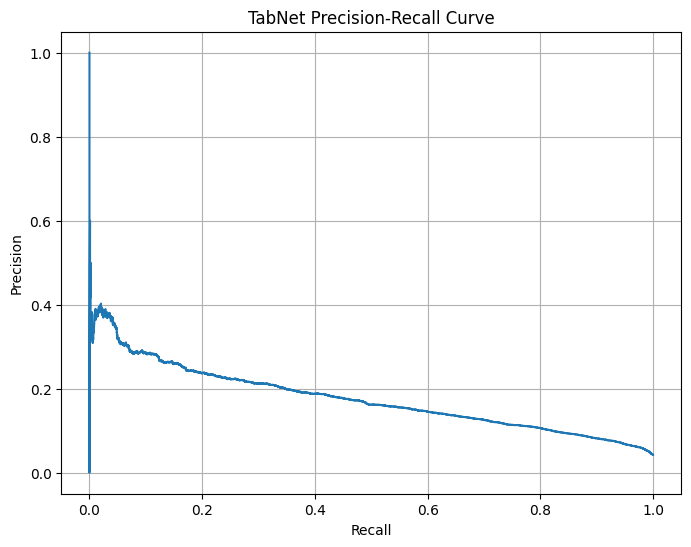

In [13]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_prob
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("TabNet Precision-Recall Curve")
plt.grid()
plt.show()

In [14]:
print("PR-AUC:", average_precision_score(y_val, val_prob))

PR-AUC: 0.17643453610880053


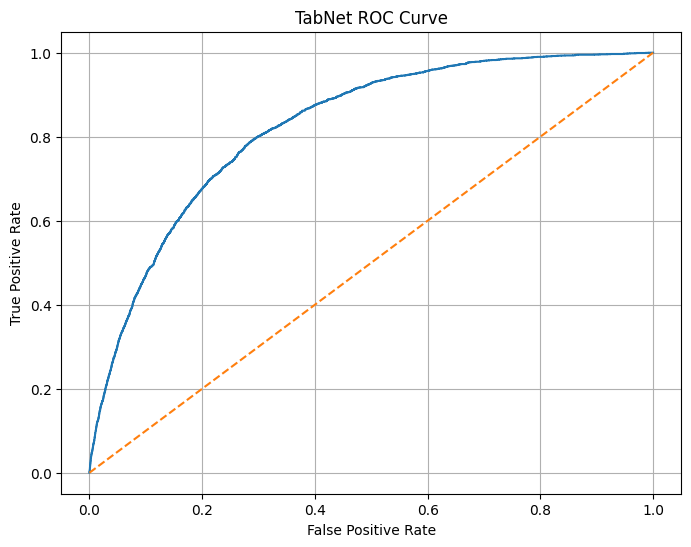

In [15]:
fpr, tpr, _ = roc_curve(y_val, val_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TabNet ROC Curve")
plt.grid()
plt.show()

In [16]:
print("ROC-AUC:", roc_auc_score(y_val, val_prob))

ROC-AUC: 0.8235722304523923


In [17]:
val_pred = tabnet.predict(X_val.values)

In [18]:
thresholds = np.arange(0.01, 1.00, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    pred = (val_prob >= threshold).astype(int)

    score = f1_score(y_val, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)

Best threshold: 0.73
Best validation F1: 0.2567665664212382


In [19]:
val_pred = (val_prob >= best_threshold).astype(int)

In [20]:
print("Accuracy:", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred))
print("Recall:", recall_score(y_val, val_pred))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_prob))
print("PR-AUC:", average_precision_score(y_val, val_prob))

Accuracy: 0.8962041448826196
Precision: 0.18452824564018483
Recall: 0.4219495569188821
F1: 0.2567665664212382
ROC-AUC: 0.8235722304523923
PR-AUC: 0.17643453610880053


In [21]:
print("\nClassification Report:")
print(classification_report(y_val, val_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     66115
           1       0.18      0.42      0.26      2934

    accuracy                           0.90     69049
   macro avg       0.58      0.67      0.60     69049
weighted avg       0.94      0.90      0.91     69049



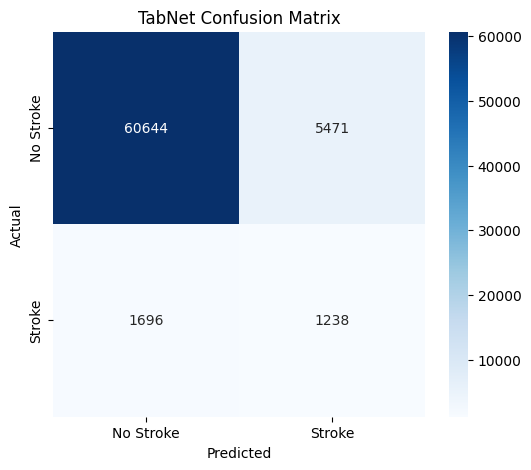

In [22]:
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TabNet Confusion Matrix")
plt.show()

In [23]:
model_path = "../models/tabnet_stroke_model"

tabnet.save_model(model_path)

print(f"TabNet model saved to: {model_path}")

Successfully saved model at ../models/tabnet_stroke_model.zip
TabNet model saved to: ../models/tabnet_stroke_model


In [24]:
import pickle

metadata = {
    "model_name": "TabNet",
    "target": TARGET,
    "threshold": best_threshold,
    "random_state": RANDOM_STATE,
    "feature_columns": list(X.columns),
    "validation_accuracy": accuracy_score(y_val, val_pred),
    "validation_precision": precision_score(y_val, val_pred),
    "validation_recall": recall_score(y_val, val_pred),
    "validation_f1": f1_score(y_val, val_pred),
    "validation_roc_auc": roc_auc_score(y_val, val_prob),
    "validation_pr_auc": average_precision_score(y_val, val_prob)
}

with open("../models/tabnet_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

print("TabNet metadata saved.")

TabNet metadata saved.
